# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
# Add auto reload:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

In [3]:
pulse_sequence = [[[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2745087, 2825086, 2892085, 2972084, 3039083, 3119082, 3186081, 3266080, 3333079, 3413078, 3480077, 3560076, 3627075, 3707074, 3774073, 3854072, 5921071, 5988070, 6068069, 6135068, 6215067, 6282066, 6362065, 6429064, 6509063, 6576062, 6656061, 6723060, 6803059, 6870058, 6950057, 7017056, 7097055, 7164054, 7249231, 7485775, 7547559, 7855415, 7935414, 8002413, 8082412, 8149411, 8229410, 8296409, 8376408, 8443407, 8523406, 8590405, 8670404, 8737403, 8817402, 8884401, 8964400, 9031399, 9111398, 9178397, 9258396, 9325395, 9405394, 9472393, 9552392, 9619391, 9699390, 9766389, 9846388, 9913387, 10043393, 10123392, 10190391, 10270390, 10337389, 10417388, 10484387, 10564386, 10631385, 10711384, 10778383, 10858382, 10925381, 11005380, 11072379, 11152378, 11219377, 11299376, 11366375, 11446374, 11513373, 11593372, 11660371, 11740370, 11807369, 11887368, 11954367, 12034366, 12101365, 12389167, 12497015, 12575542, 12883399, 12963398, 13030397, 13110396, 13177395, 13257394, 13324393, 13404392, 13471391, 13551390, 13618389, 13698388, 13765387, 13845386, 13912385, 13992384, 14059383, 14139382, 14206381, 14286380, 14353379, 14433378, 14500377, 14580376, 14647375, 14727374, 14794373, 14874372, 14941371, 15071378, 15151377, 15218376, 15298375, 15365374, 15445373, 15512372, 15592371, 15659370, 15739369, 15806368, 15886367, 15953366, 16033365, 16100364, 16180363, 16247362, 16327361, 16394360, 16474359, 16541358, 16621357, 16688356, 16768355, 16835354, 16915353, 16982352, 17062351, 17129350, 17417143, 17528663], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 49999, 99999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 99999, 68000, 99999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 99999, 34000], [80000000, 79972625, 79989657, 80002065, 80006393, 79985329, 80023129, 79968593, 80039865, 79951857, 80056601, 79935121, 80073337, 79918385, 80090073, 79901649, 80106809, 79884913, 80083135, 79925323, 80066399, 79942059, 80049663, 79958795, 80032927, 79975531, 80016191, 79992267, 79999455, 80009004, 79982719, 80025740, 79965983, 80042476, 79949247, 80059212, 79933229, 80073494, 79918805, 80087304, 79904618, 80104041, 79887882, 80120777, 79871146, 80137513, 79854410, 80154249, 79837674, 80170985, 79820937, 80187721, 79804201, 80204457, 79787465, 80221193, 79770729, 80237929, 79753993, 80254665, 79737257, 80271401, 79720521, 80288137, 79703785, 80304873, 79687049, 80321609, 80319584, 79690938, 80298720, 79711802, 80277856, 79732666, 80256992, 79753530, 80236128, 79774394, 80215264, 79795258, 80194400, 79816122, 80173536, 79836986, 80152672, 79857850, 80131808, 79878714, 80110944, 79899578, 80090080, 79920442, 80069216, 79941306, 80048352, 79962170, 80027488, 79986585, 80002933, 79989201, 80016508, 79975214, 80033244, 79958478, 80049980, 79941742, 80066716, 79925006, 80083452, 79908270, 80100188, 79891534, 80116924, 79874798, 80133661, 79858062, 80150397, 79841326, 80167133, 79824590, 80183869, 79807854, 80200605, 79791118, 80217341, 79774381, 80234077, 79757645, 80250813, 80248987, 79761535, 80228124, 79782399, 80207260, 79803263, 80186396, 79824127, 80165532, 79844991, 80144668, 79865854, 80123804, 79886718, 80102940, 79907582, 80082076, 79928446, 80061212, 79949310, 80040348, 79970174, 80019484, 79991038, 79998620, 80011902, 79977756, 80032766, 79956892, 80056181, 79932555], [200000000, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800], [99480600, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], [[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2945087, 3025086, 3092085, 3172084, 3239083, 3319082, 3386081, 3466080, 3533079, 3613078, 3680077, 3760076, 3827075, 3907074, 3974073, 4054072, 6121071, 6188070, 6268069, 6335068, 6415067, 6482066, 6562065, 6629064, 6709063, 6776062, 6856061, 6923060, 7003059, 7070058, 7150057, 7217056, 7297055, 7364054, 7449231, 7685775, 7747559, 8055415, 8135414, 8202413, 8282412, 8349411, 8429410, 8496409, 8576408, 8643407, 8723406, 8790405, 8870404, 8937403, 9017402, 9084401, 9164400, 9231399, 9311398, 9378397, 9458396, 9525395, 9605394, 9672393, 9752392, 9819391, 9899390, 9966389, 10046388, 10113387, 10243393, 10323392, 10390391, 10470390, 10537389, 10617388, 10684387, 10764386, 10831385, 10911384, 10978383, 11058382, 11125381, 11205380, 11272379, 11352378, 11419377, 11499376, 11566375, 11646374, 11713373, 11793372, 11860371, 11940370, 12007369, 12087368, 12154367, 12234366, 12301365, 12589167, 12697015, 12775542, 13083399, 13163398, 13230397, 13310396, 13377395, 13457394, 13524393, 13604392, 13671391, 13751390, 13818389, 13898388, 13965387, 14045386, 14112385, 14192384, 14259383, 14339382, 14406381, 14486380, 14553379, 14633378, 14700377, 14780376, 14847375, 14927374, 14994373, 15074372, 15141371, 15271378, 15351377, 15418376, 15498375, 15565374, 15645373, 15712372, 15792371, 15859370, 15939369, 16006368, 16086367, 16153366, 16233365, 16300364, 16380363, 16447362, 16527361, 16594360, 16674359, 16741358, 16821357, 16888356, 16968355, 17035354, 17115353, 17182352, 17262351, 17329350, 17617143, 17728663], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 49999, 99999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 99999, 68000, 99999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 99999, 34000], [80000000, 79972625, 79986849, 80004873, 80003585, 79988137, 80020321, 79971401, 80037057, 79954665, 80053793, 79937929, 80070529, 79921193, 80087265, 79904457, 80104001, 79887721, 80085943, 79922515, 80069207, 79939251, 80052471, 79955987, 80035735, 79972723, 80018999, 79989459, 80002263, 80006195, 79985527, 80022931, 79968791, 80039667, 79952055, 80056404, 79936037, 80070686, 79921613, 80084496, 79907426, 80101232, 79890690, 80117968, 79873954, 80134705, 79857218, 80151441, 79840482, 80168177, 79823746, 80184913, 79807010, 80201649, 79790274, 80218385, 79773537, 80235121, 79756801, 80251857, 79740065, 80268593, 79723329, 80285329, 79706593, 80302065, 79689857, 80318801, 80316776, 79693747, 80295912, 79714611, 80275048, 79735474, 80254184, 79756338, 80233320, 79777202, 80212456, 79798066, 80191592, 79818930, 80170728, 79839794, 80149864, 79860658, 80129000, 79881522, 80108136, 79902386, 80087272, 79923250, 80066408, 79944114, 80045544, 79964978, 80024680, 79989393, 80000125, 79992009, 80013700, 79978022, 80030436, 79961286, 80047172, 79944550, 80063908, 79927814, 80080644, 79911078, 80097380, 79894342, 80114116, 79877606, 80130852, 79860870, 80147588, 79844134, 80164325, 79827398, 80181061, 79810662, 80197797, 79793926, 80214533, 79777190, 80231269, 79760454, 80248005, 80246179, 79764343, 80225315, 79785207, 80204451, 79806071, 80183588, 79826935, 80162724, 79847799, 80141860, 79868663, 80120996, 79889527, 80100132, 79910391, 80079268, 79931254, 80058404, 79952118, 80037540, 79972982, 80016676, 79993846, 79995812, 80014710, 79974948, 80035574, 79954084, 80058989, 79929747], [200000500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800], [99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800, 99479800], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
# Cut after the launch

t_launch_finished = 5e-3

is_before_launch = start_times_mu * 1e-9 < t_launch_finished

is_up = is_up[is_before_launch]
start_times_mu = start_times_mu[is_before_launch]
durations_mu = durations_mu[is_before_launch]
opll_hz = opll_hz[is_before_launch]
switch_hz = switch_hz[is_before_launch]
delivery_hz = delivery_hz[is_before_launch]
delivery_setpoint = delivery_setpoint[is_before_launch]

In [7]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
# probe_shift_alpha, initial_velocity_z = (
#     seq.calibrate_probe_shift_and_velocity_from_dump(
#         is_up=is_up,
#         start_times_mu=start_times_mu,
#         durations_mu=durations_mu,
#         opll_hz=opll_hz,
#         switch_hz=switch_hz,
#         delivery_hz=delivery_hz,
#         delivery_setpoint=delivery_setpoint,
#     )
# )

# # FIXME
# # probe_shift_alpha = -2e-5

# print(f"auto-calibrated probe-shift alpha = {probe_shift_alpha:.4e} /Hz")
# print(f"auto-calibrated initial velocity  = {initial_velocity_z:.4e} m/s")

# probe_shift_ref = probe_shift_alpha * (1/(2*t_pi_ref))**2
# print(f"probe shift with a {1e6*t_pi_ref:.0f} us pi pulse = {1e-3*probe_shift_ref:.2f} kHz")

t_pi_ref = 55e-6

probe_shift_known = -1.5e3
probe_shift_alpha = probe_shift_known / (1/(2*t_pi_ref))**2
print(f"calibrated probe-shift alpha = {probe_shift_alpha:.4e} /Hz")

# FIXME
initial_velocity_z = 0.0

calibrated probe-shift alpha = -1.8150e-05 /Hz


In [8]:
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)

# Skip the first freefall
# sequence = sequence[1:]

In [9]:
def plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=False):
    raw_detunings_recoil = []
    corrected_detunings_recoil = []
    pulse_colours = []
    pulse_hatches = []
    clearout_links = []

    last_pulse_index = None
    clearout_since_last_pulse = False

    PULSE_STYLES = {
        #              colour          hatch
        (True, True): ("tab:orange", ""),  # up,   pi
        (True, False): ("tab:blue", "///"),  # up,   pi/2
        (False, True): ("tab:red", "\\\\"),  # down, pi
        (False, False): ("tab:purple", "xxx"),  # down, pi/2
    }

    timestamps = []
    pulse_durations = []
    now = 0.0
    for event in plot_sequence:
        if isinstance(event, seq.Clearout):
            clearout_since_last_pulse = True
            now += event.duration
            continue

        if not isinstance(event, seq.Pulse):
            now += event.duration
            continue

        timestamps.append(now + event.duration / 2)
        pulse_durations.append(event.duration)
        now += event.duration

        pulse_index = len(raw_detunings_recoil)
        raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
        probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2
        corrected_detunings_recoil.append(
            (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
        )

        colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
        pulse_colours.append(colour)
        pulse_hatches.append(hatch)

        if last_pulse_index is not None and clearout_since_last_pulse:
            clearout_links.append((last_pulse_index, pulse_index))

        last_pulse_index = pulse_index
        clearout_since_last_pulse = False

    pulse_indices = np.arange(len(raw_detunings_recoil))

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_detunings = (
        corrected_detunings_recoil if plot_corrected else raw_detunings_recoil
    )

    x_axis = timestamps if plot_by_timestamp else pulse_indices

    bars = ax.bar(x_axis, plot_detunings, color=pulse_colours, width= pulse_durations if plot_by_timestamp else 0.9)
    for bar, hatch in zip(bars, pulse_hatches):
        bar.set_hatch(hatch)

    for left_index, right_index in clearout_links:
        ax.plot(
            [x_axis[left_index], x_axis[right_index]],
            [
                plot_detunings[left_index],
                plot_detunings[right_index],
            ],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            zorder=3,
        )

    if not plot_by_timestamp:
        tick_step = max(1, len(pulse_indices) // 20)
        ax.set_xticks(pulse_indices[::tick_step])
        ax.set_xlabel("Pulse index")
    else:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Detuning (recoil frequencies)")
    ax.grid(axis="y", alpha=0.25)

    # Show where the uncorrected (raw) detuning sat, for comparison.
    if plot_corrected:
        ax.scatter(
            x_axis,
            raw_detunings_recoil,
            facecolor="none",
            edgecolor="0.2",
            marker="o",
            s=40,
            zorder=4,
        )

    y_min, y_max = ax.get_ylim()
    ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
    ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

    legend_handles = [
        Patch(facecolor="tab:orange", hatch="", label="up, pi"),
        Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
        Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
        Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    ]
    if clearout_links:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:green",
                linestyle=":",
                linewidth=2,
                label="clearout between pulses",
            )
        )

    ax.legend(handles=legend_handles, loc="upper left", frameon=False)

In [10]:

_, plot_sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=-1.5e-3,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)
# plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:16]


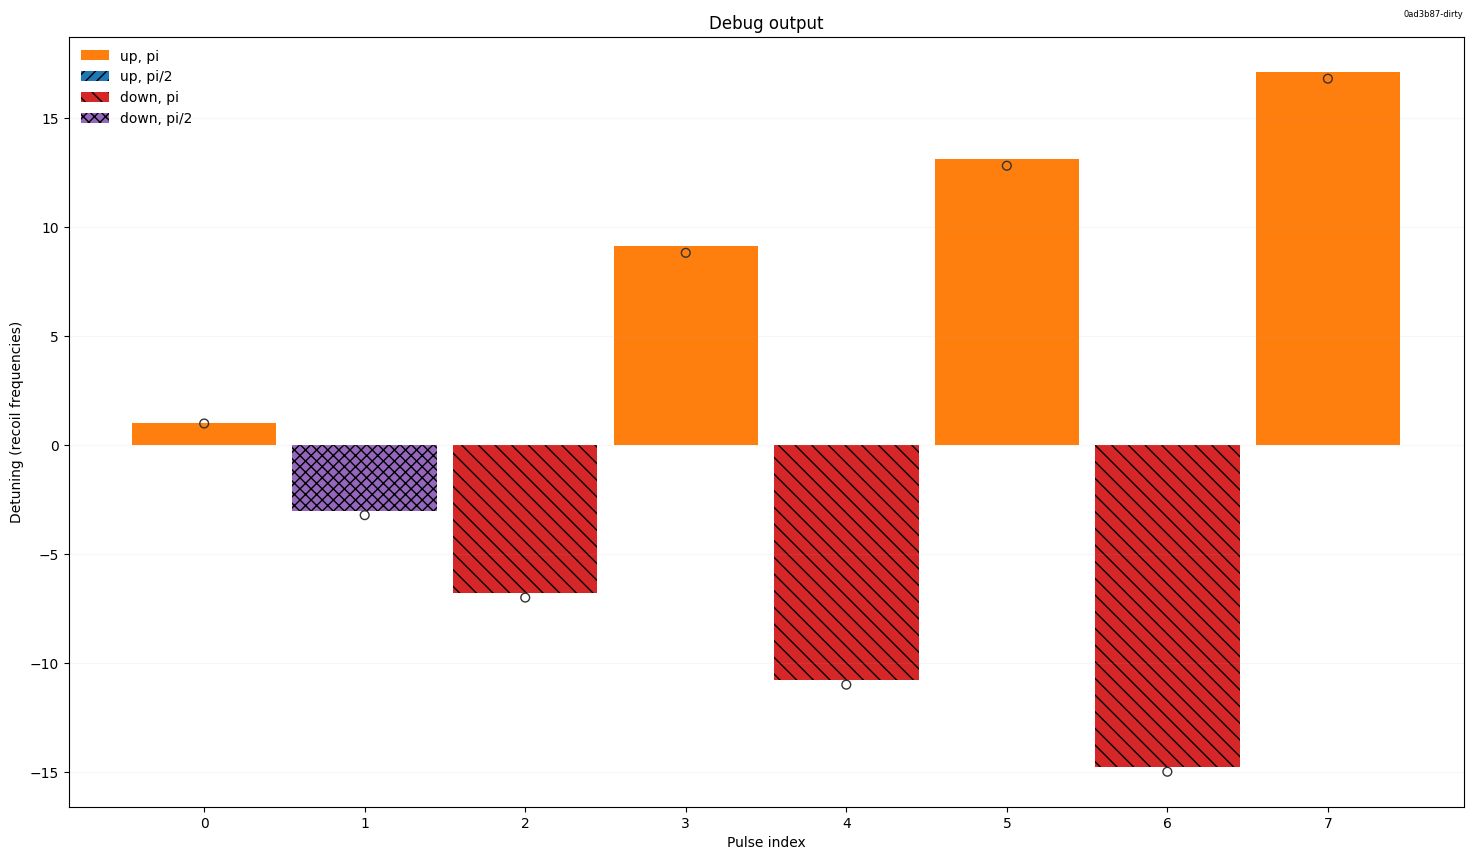

In [11]:
plot_lab_pulse_sequence(plot_sequence, plot_corrected=True)
plt.title("Debug output")
vs.tag_plot(small=True);

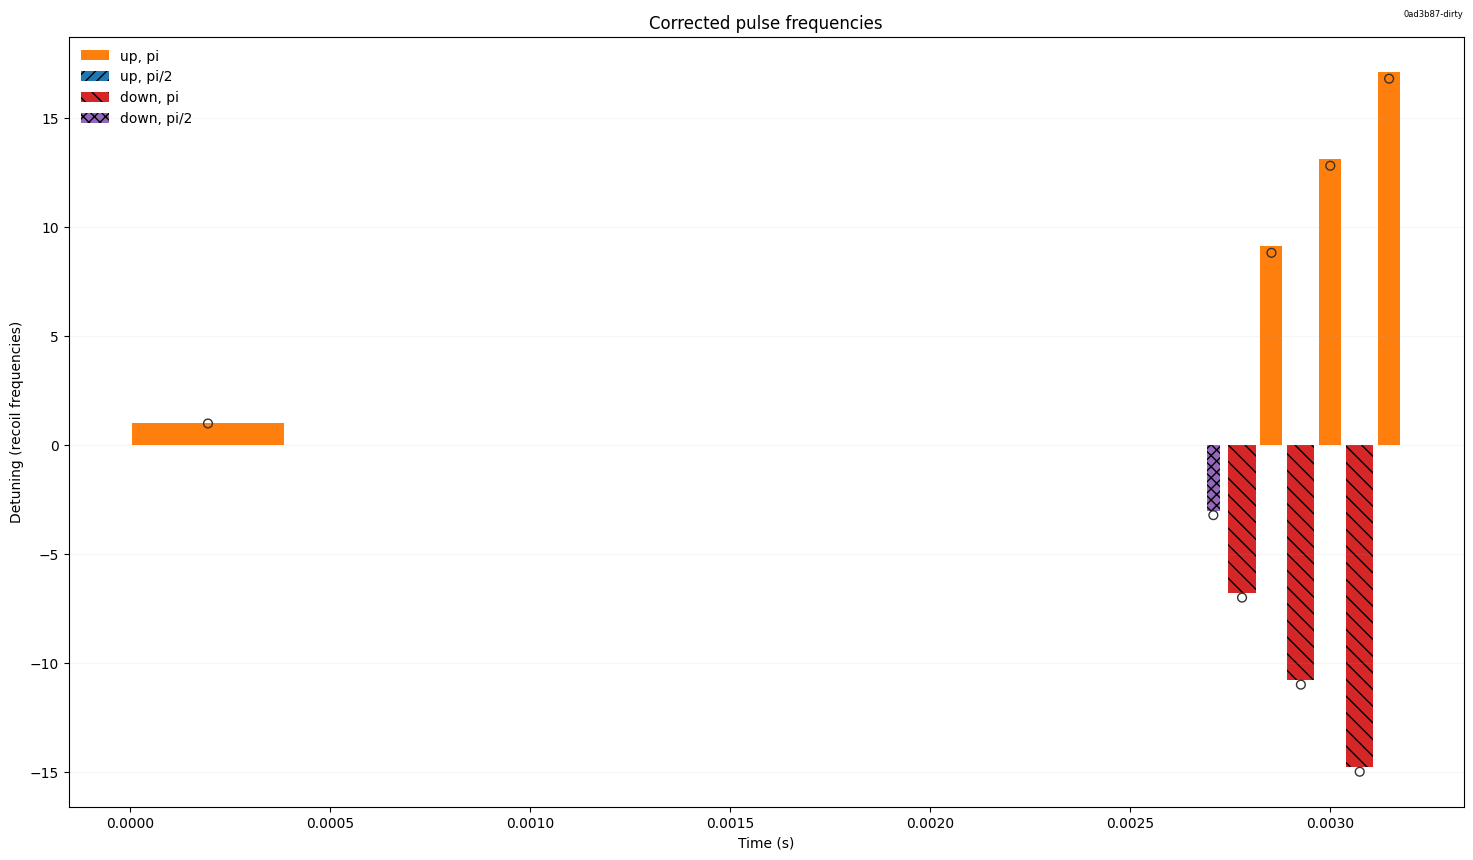

In [12]:
plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=True)
plt.title("Corrected pulse frequencies")
vs.tag_plot(small=True);

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.002745087), np.float64(0.0028130869999999997), np.float64(0.0028250859999999997), np.float64(0.0028800849999999997), np.float64(0.0028920849999999995), np.float64(0.0029600849999999995), np.float64(0.002972084), np.float64(0.003027083), np.float64(0.0030390829999999997), np.float64(0.0031070829999999996), np.float64(0.0031190819999999996), np.float64(0.0031740809999999996), np.float64(0.003186081), np.float64(0.003254081), np.float64(0.0032660799999999998), np.float64(0.003321079), np.float64(0.0033330789999999996), np.float64(0.0034010789999999996), np.float64(0.003413078), np.float64(0.003468077), np.float64(0.003480077), np.float64(0.0035480769999999997), np.float64(0.0035600759999999997), np.float64(0.0036150749999999997), np.float64(0.003627075), np.float64(0.003695075), np.float64(0

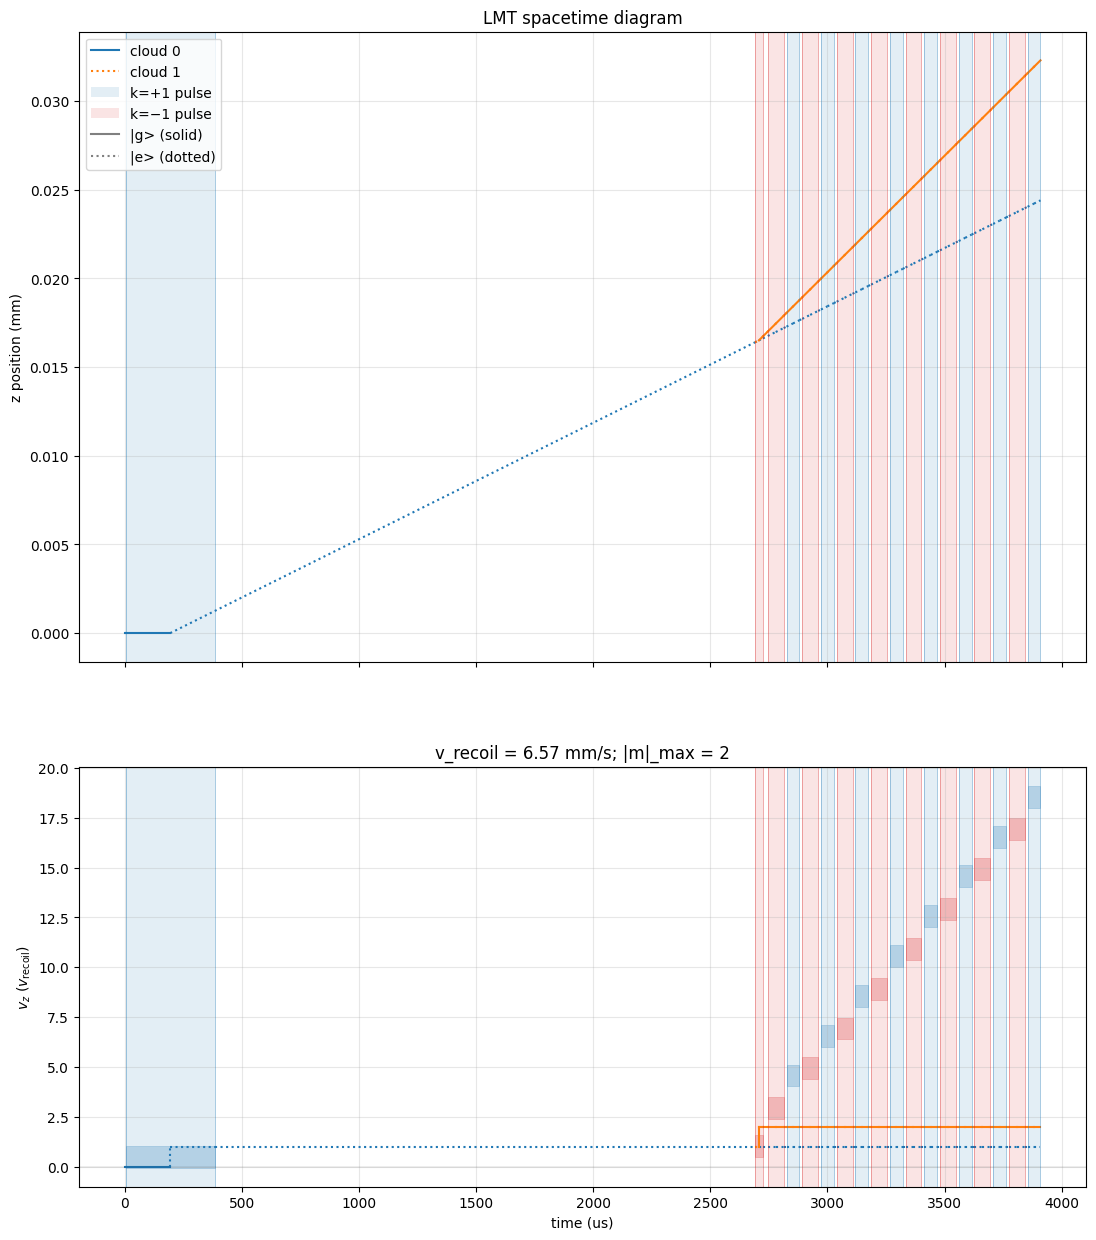

In [13]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20, flip_threshold=0.6)


In [14]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)

bodged_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        bodged_sequence.append(event)
        continue

    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2

    closest_integer = int(round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ))
    corrected_detuning = closest_integer * sim.RECOIL_FREQUENCY_HZ

    new_pulse = seq.Pulse(
        k=event.k,
        duration=event.duration,
        detuning_hz=corrected_detuning,
        rabi_frequency=event.rabi_frequency,
        phi=event.phi,
        label=event.label,
        probe_shift_coefficient=event.probe_shift_coefficient,
    )
    bodged_sequence.append(new_pulse)
    
# seq.compute_spacetime_trajectory(new_sequence, plot=True, max_branches=20)

bodged_sequence


[Freefall(duration=np.float64(4.936000000000001e-06), label='freefall'),
 Pulse(k=1, detuning_hz=4707.028607971276, phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0, probe_shift_coefficient=-1.815e-05),
 Freefall(duration=np.float64(0.002305463), label='freefall'),
 Pulse(k=-1, detuning_hz=-9414.057215942552, phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(3.4e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.815e-05),
 Freefall(duration=np.float64(2.0688000000000043e-05), label='freefall'),
 Pulse(k=-1, detuning_hz=-28242.171647827658, phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.815e-05),
 Freefall(duration=np.float64(1.199899999999995e-05), label='freefall'),
 Pulse(k=1, detuning_hz=42363.25747174148, phi=0.0, label='LMT', rabi_frequency=np.float64(9091.074383170602), 

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.002745087), np.float64(0.0028130869999999997), np.float64(0.0028250859999999997), np.float64(0.0028800849999999997), np.float64(0.0028920849999999995), np.float64(0.0029600849999999995), np.float64(0.002972084), np.float64(0.003027083), np.float64(0.0030390829999999997), np.float64(0.0031070829999999996), np.float64(0.0031190819999999996), np.float64(0.0031740809999999996), np.float64(0.003186081), np.float64(0.003254081), np.float64(0.0032660799999999998), np.float64(0.003321079), np.float64(0.0033330789999999996), np.float64(0.0034010789999999996), np.float64(0.003413078), np.float64(0.003468077), np.float64(0.003480077), np.float64(0.0035480769999999997), np.float64(0.0035600759999999997), np.float64(0.0036150749999999997), np.float64(0.003627075), np.float64(0.003695075), np.float64(0

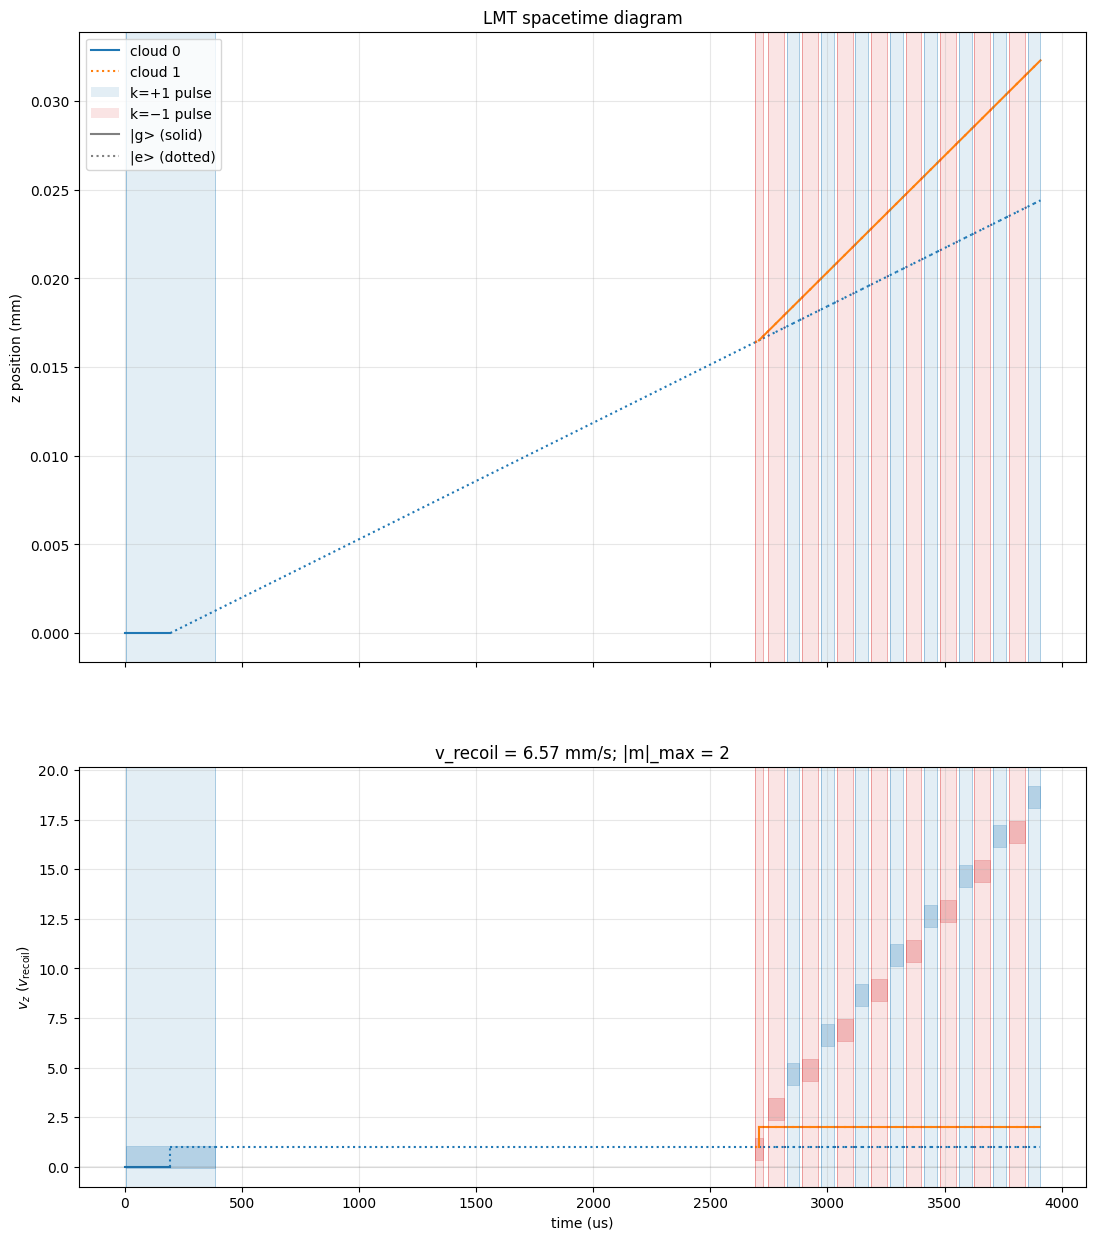

In [15]:
seq.compute_spacetime_trajectory(bodged_sequence, plot=True, max_branches=20)
